In [1]:
#install dependencies
!pip install transformers==4.37.0 torch torchvision easyocr pillow

  Obtaining dependency information for numpy>=1.17 from https://files.pythonhosted.org/packages/78/51/9f5d7a41f0b51649ddf2f2320595e15e122a40610b233d51928dd6c92353/numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata
  Using cached numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached numpy-2.4.3-cp311-cp311-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.9 MB)
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.4
    Uninstalling numpy-1.26.4:
      Successfully uninstalled numpy-1.26.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
pandas 2.1.4 requires numpy<2,>=1.23.2; python_version == "3.11", but you have numpy 2.4.3 which is incompatible.
scikit-learn 1.3.2 requires numpy<2.0,>=1.17.3, but you have numpy 2.4.3 which is incompatible.

[notice] A new rele

In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import os

/usr/local/lib/python3.11/dist-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.16) or chardet (7.1.0)/charset_normalizer (3.2.0) doesn't match a supported version!
  warnings.warn(


In [1]:
#aligning scikint learn version to work with pandas version, restart kernel if asked and run again
import sys
import os
import site

# 1. Force the 'User Site' to the top
user_site = site.getusersitepackages()
if user_site not in sys.path:
    sys.path.insert(0, user_site)

# 2. Re-align scikit-learn to match our NumPy 1.26.4
try:
    import numpy as np
    import pandas as pd
    from sklearn.model_selection import train_test_split
    print(f"✅ Success! Environment Aligned.")
except (ImportError, ValueError):
    print("Aligning Scikit-Learn... please wait.")
    !pip install --user --force-reinstall scikit-learn==1.3.2
    print("⚠️ RESTART KERNEL NOW, then run this cell again.")
    sys.exit()

# 3. Load and Split
df = pd.read_csv("V4.0_TRAIN_FINAL_CLEANED.csv")

# Clean any empty rows that might have snuck in during OCR
df = df.dropna(subset=['text', 'label'])

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["label"],
    random_state=42
)

print(f"Train size: {len(train_df)} | Test size: {len(test_df)}")
print(train_df['label'].value_counts())


✅ Success! Environment Aligned.
Train size: 13100 | Test size: 3275
label
2    6206
1    4172
0    2722
Name: count, dtype: int64


In [2]:
print(train_df["text"])

9537     yo what's up, so like my doc said i should get...
4040     just got these lab things back, looks like eve...
6270     yo check this outâ€”lab report came in, patien...
13822    os hospital trauma center biochemistry report ...
11026    9810536755 shree hospital my doctor' s plot no...
                               ...                        
13888    so i was reading this old doc and it said mchc...
12064    bro, i got these lab numbers back and iâ€™m ki...
7127     metro cure hospitals clinical report laborator...
13603    gst appli3d m3dicin3s: r3mdac, m3p3m blue blis...
5222     apparently my lab report says things like prot...
Name: text, Length: 13100, dtype: object


In [3]:
from torch.utils.data import Dataset
import torch
import pandas as pd

class OCRDataset(Dataset):

    def __init__(self,df,tokenizer,max_len=128):

        self.df = df
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.df)

    def __getitem__(self,idx):

        text = str(self.df.iloc[idx]["text"])
        label = int(self.df.iloc[idx]["label"])

        enc = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        item = {k:v.squeeze(0) for k,v in enc.items()}
        if "token_type_ids" in item:
            del item["token_type_ids"]

        item["labels"] = torch.tensor(label,dtype=torch.long)

        return item

In [4]:
def predict(image_path):

    text = extract_text(image_path)

    inputs = tokenizer(
        text,
        padding=True,
        truncation=True,
        return_tensors="pt"
    )

    outputs = model(**inputs)
    logits = outputs.logits

    predicted_class = torch.argmax(logits, dim=1).item()

    return predicted_class

In [5]:
#wait a few second before running next cell to load tokenizer
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

MODEL_NAME = "bert-mini"   # replace with your nano-bert
# MODEL_NAME = "NeuML/bert-hash-nano"   # replace with your nano-bert

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

model = AutoModelForSequenceClassification.from_pretrained(
    "./bert-mini", 
    num_labels=3, 
    ignore_mismatched_sizes=True
)

/usr/local/lib/python3.11/dist-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (1.26.16) or chardet (7.1.0)/charset_normalizer (3.2.0) doesn't match a supported version!
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at ./bert-mini and are newly initialized: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
#wait for the model to load
enc = tokenizer("test sentence", return_tensors="pt")

print(enc["input_ids"].max())
print(model.config.vocab_size)

tensor(6251)
30522


In [7]:
from torch.utils.data import Dataset, DataLoader
train_dataset = OCRDataset(train_df, tokenizer)
test_dataset = OCRDataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

In [8]:
print(train_dataset[0])

{'input_ids': tensor([  101, 10930,  2054,  1005,  1055,  2039,  1010,  2061,  2066,  2026,
         9986,  2056,  1045,  2323,  2131,  2122,  5852,  2589,  1010,  1998,
         2651,  1045,  2106,  2050, 30102,  1524,  4332,  2041,  2026,  2668,
         4933,  2003, 17704,  3748,  2066, 23859,  1012,  6227,  1045,  5313,
         2005, 13675,  2361,  2008,  1005,  1055,  2152,  2157,  2036,  1996,
         6845,  2518,  2100,  2018, 26794,  2102,  2012,  2538,  1012,  6640,
         1010,  2025,  2469,  2065,  2008,  5609,  1010,  2021,  4312,  2027,
         2165,  2009,  2006, 16798,  2629,  1011,  2260,  1011,  2539,  1010,
         5776,  8909,  4444, 17788,  1010,  3649,  2008,  2965,  8840,  2140,
         1012,  4312,  1045,  2514,  2986,  1010,  2672,  2074,  5458,   102,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0, 

In [9]:
import pandas as pd

train_df = pd.read_csv("V4.0_TRAIN_FINAL_CLEANED.csv")

print(train_df["label"].unique())
print(train_df["label"].min(), train_df["label"].max())

[1 0 2]
0 2


In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model.to(device)


BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-12, e

In [11]:
print(model)

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 128, padding_idx=0)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-3): 4 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm): LayerNorm((128,), eps=1e-12, e

In [12]:
print("Unique labels in training data:", train_df['label'].unique())
print("Count of each label:\n", train_df['label'].value_counts())


Unique labels in training data: [1 0 2]
Count of each label:
 label
2    7778
1    5215
0    3402
Name: count, dtype: int64


In [13]:
# import torch.nn as nn

# # [Prescription: 1.0, Report: 1.0, Others: 3.0]
# # We give Others 3x importance so the model "studies" the gibberish harder
# weights = torch.tensor([1.0, 1.0, 3.0], dtype=torch.float).to(device)
# loss_fn = nn.CrossEntropyLoss(weight=weights)


In [14]:
# 1. Define your mapping (adjust if your labels are different)
# mapping = {0: "Prescription", 1: "Report", 2: "Others"}

# print("--- 🕵️ DATASET AUDIT ---")
# for label_id, label_name in mapping.items():
#     # Count how many rows have this label
#     count = len(train_df[train_df['label'] == label_id])
    
#     # Get a real text sample from this label
#     sample_text = train_df[train_df['label'] == label_id]['text'].iloc[0] if count > 0 else "NO DATA"
    
#     print(f"\nLabel [{label_id}] -> {label_name}")
#     print(f"📊 Total Count: {count}")
#     print(f"📝 Sample Text: {sample_text[:150]}...") # Show first 150 chars
#     print("-" * 30)

# # 2. Total Samples for Weight Logic
# total = len(train_df)
# print(f"\n🌍 Total Dataset Size: {total}")


In [15]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Get classes in exact sorted order: [0, 1, 2]
classes = np.sort(train_df['label'].unique())

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_df['label']
)

# Correct mapping based on your counts:
print(f"📊 COUNTS: {train_df['label'].value_counts().to_dict()}")
print(f"⚖️ WEIGHTS:")
print(f"   - [0] Prescription  : {class_weights[0]:.2f}")
print(f"   - [1] Report        : {class_weights[1]:.2f} ")
print(f"   - [2] Others       : {class_weights[2]:.2f} ")

import torch

# 1. Convert the weights array to a PyTorch Tensor
# Ensure it is moved to the same 'device' (cuda or cpu) as your model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

# 2. Define the Loss Function with the weights
# This is the 'loss_fn' your training loop will use
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)
loss_fn = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"✅ Loss Function initialized with class weights on {device}")



📊 COUNTS: {2: 7778, 1: 5215, 0: 3402}
⚖️ WEIGHTS:
   - [0] Prescription  : 1.61
   - [1] Report        : 1.05 
   - [2] Others       : 0.70 
✅ Loss Function initialized with class weights on cuda


In [16]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class FocalLossWithMargin(nn.Module):
#     def __init__(self, alpha=None, gamma=2.0, smoothing=0.1):
#         # Fixed the double underscores here 
#         super(FocalLossWithMargin, self).__init__() 
#         self.alpha = alpha 
#         self.gamma = gamma
#         self.smoothing = smoothing

#     def forward(self, logits, targets):
#         num_classes = logits.size(-1)
#         log_probs = F.log_softmax(logits, dim=-1)
        
#         with torch.no_grad():
#             true_dist = torch.zeros_like(log_probs)
#             true_dist.fill_(self.smoothing / (num_classes - 1))
#             true_dist.scatter_(1, targets.data.unsqueeze(1), 1.0 - self.smoothing)

#         probs = torch.exp(log_probs)
#         focal_weight = (1 - probs) ** self.gamma
        
#         if self.alpha is not None:
#             # Applying weights to the smoothed loss
#             loss = -self.alpha[targets].view(-1, 1) * focal_weight * true_dist * log_probs
#         else:
#             loss = -focal_weight * true_dist * log_probs

#         return loss.sum(dim=-1).mean()

# # --- NOW RUN THIS ---
# # Ensure class_weights is already defined and moved to device
# loss_fn = FocalLossWithMargin(alpha=class_weights_tensor, gamma=2.0, smoothing=0.1)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-5)


In [17]:
from tqdm import tqdm
import torch

best_val_loss = float("inf")

EPOCHS = 4

for epoch in range(EPOCHS):

    # ---------------- TRAIN ----------------
    model.train()
    train_loss = 0

    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1} Training")

    for batch in train_bar:

        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        logits = outputs.logits
        loss = loss_fn(logits, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_bar.set_postfix(loss=loss.item())

    avg_train_loss = train_loss / len(train_loader)

    # ---------------- VALIDATION (With Safety Filter) ----------------
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    val_bar = tqdm(test_loader, desc=f"Epoch {epoch+1} Validation")

    with torch.no_grad():
        for batch in val_bar:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            
            # --- NEW LOGIC START ---
            probs = torch.softmax(logits, dim=1)
            # Get top 2 probabilities
            top_p, top_idx = torch.topk(probs, k=2, dim=1)
            
            conf = top_p[:, 0] # Top probability
            margin = top_p[:, 0] - top_p[:, 1] # Difference
            
            # Apply your Business Rule: If conf < 0.7 OR margin < 0.3 -> Class 2 (Others)
            # Otherwise, use the original top_idx
            final_preds = torch.where((conf < 0.75) | (margin < 0.3), torch.tensor(2).to(device), top_idx[:, 0])
            # --- NEW LOGIC END ---

            loss = loss_fn(logits, labels)
            val_loss += loss.item()

            correct += (final_preds == labels).sum().item()
            total += labels.size(0)

            val_bar.set_postfix(loss=loss.item())
            avg_val_loss = val_loss / len(test_loader)
            val_accuracy = correct / total
            


    # ---------------- SAVE BEST MODEL ----------------
    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        model.save_pretrained("best_model_3class")
        tokenizer.save_pretrained("best_model_3class")

        print("Best model saved")

Epoch 1 Validation: 100%|██████████| 205/205 [00:04<00:00, 50.80it/s, loss=0.223]


Best model saved


Epoch 2 Validation: 100%|██████████| 205/205 [00:04<00:00, 49.49it/s, loss=0.0751]


Best model saved


Epoch 3 Validation: 100%|██████████| 205/205 [00:03<00:00, 53.61it/s, loss=0.0368]


Best model saved


Epoch 4 Validation: 100%|██████████| 205/205 [00:03<00:00, 54.72it/s, loss=0.026] 


Best model saved


In [18]:
print(model.classifier.weight.grad.abs().mean())

tensor(0.0253, device='cuda:0')


In [19]:
#checks for the best model and loads it
import os
import torch
from transformers import BertTokenizer, BertForSequenceClassification

# 1. The EXACT Absolute Path to your best_model folder
model_path = "best_model_3class"

# 2. Check if the folder and files exist
if not os.path.exists(model_path):
    print(f"❌ ERROR: Folder not found at {model_path}")
else:
    print(f"✅ Folder found! Files inside: {os.listdir(model_path)}")
    
    try:
        # GPU Invocation Logic
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"🚀 Loading model onto: {device}")

        # 3. Load Tokenizer and Model (Local Files Only)
        tokenizer = BertTokenizer.from_pretrained(model_path, local_files_only=True)
        model = BertForSequenceClassification.from_pretrained(model_path, local_files_only=True)

        # Move to GPU and set to evaluation mode
        model.to(device)
        model.eval()
        print("✅ Success! BERT Model and Tokenizer are ready for testing.")
        
    except Exception as e:
        print(f"❌ Load failed: {e}")


✅ Folder found! Files inside: ['tokenizer_config.json', 'config.json', 'model.safetensors', 'vocab.txt', 'special_tokens_map.json', 'tokenizer.json']
🚀 Loading model onto: cuda
✅ Success! BERT Model and Tokenizer are ready for testing.


In [ ]:
import pandas as pd
import os

test_csv = "V4.0_TEST_FINAL_CLEANED.csv"

if os.path.exists(test_csv):
    df_test = pd.read_csv(test_csv)
    print(f"✅ Loaded {len(df_test)} testing rows.")
else:
    print(f"❌ Error: {test_csv} not found! Check your file path.")

In [23]:
import torch
import pandas as pd
from tqdm import tqdm

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

predictions = []
confidence_scores = []
class_map = {0: "Prescription", 1: "Report", 2: "Others"}

print(f"🚀 Running Inference on {device}...")

model.eval() 
with torch.no_grad():
    for text in tqdm(df_test['text']):
        inputs = tokenizer(str(text), 
                           return_tensors="pt", 
                           truncation=True, 
                           padding=True, 
                           max_length=512).to(device)
        
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=1)
        conf, top_idx = torch.max(probs, dim=1)
        
        predictions.append(class_map[top_idx.item()])
        confidence_scores.append(conf.item())

# Save results
df_test['predicted_label'] = predictions
df_test['confidence'] = confidence_scores
df_test['true_label_name'] = df_test['label'].map(class_map)


🚀 Running Inference on cuda...


100%|██████████| 1822/1822 [00:09<00:00, 194.73it/s]


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  

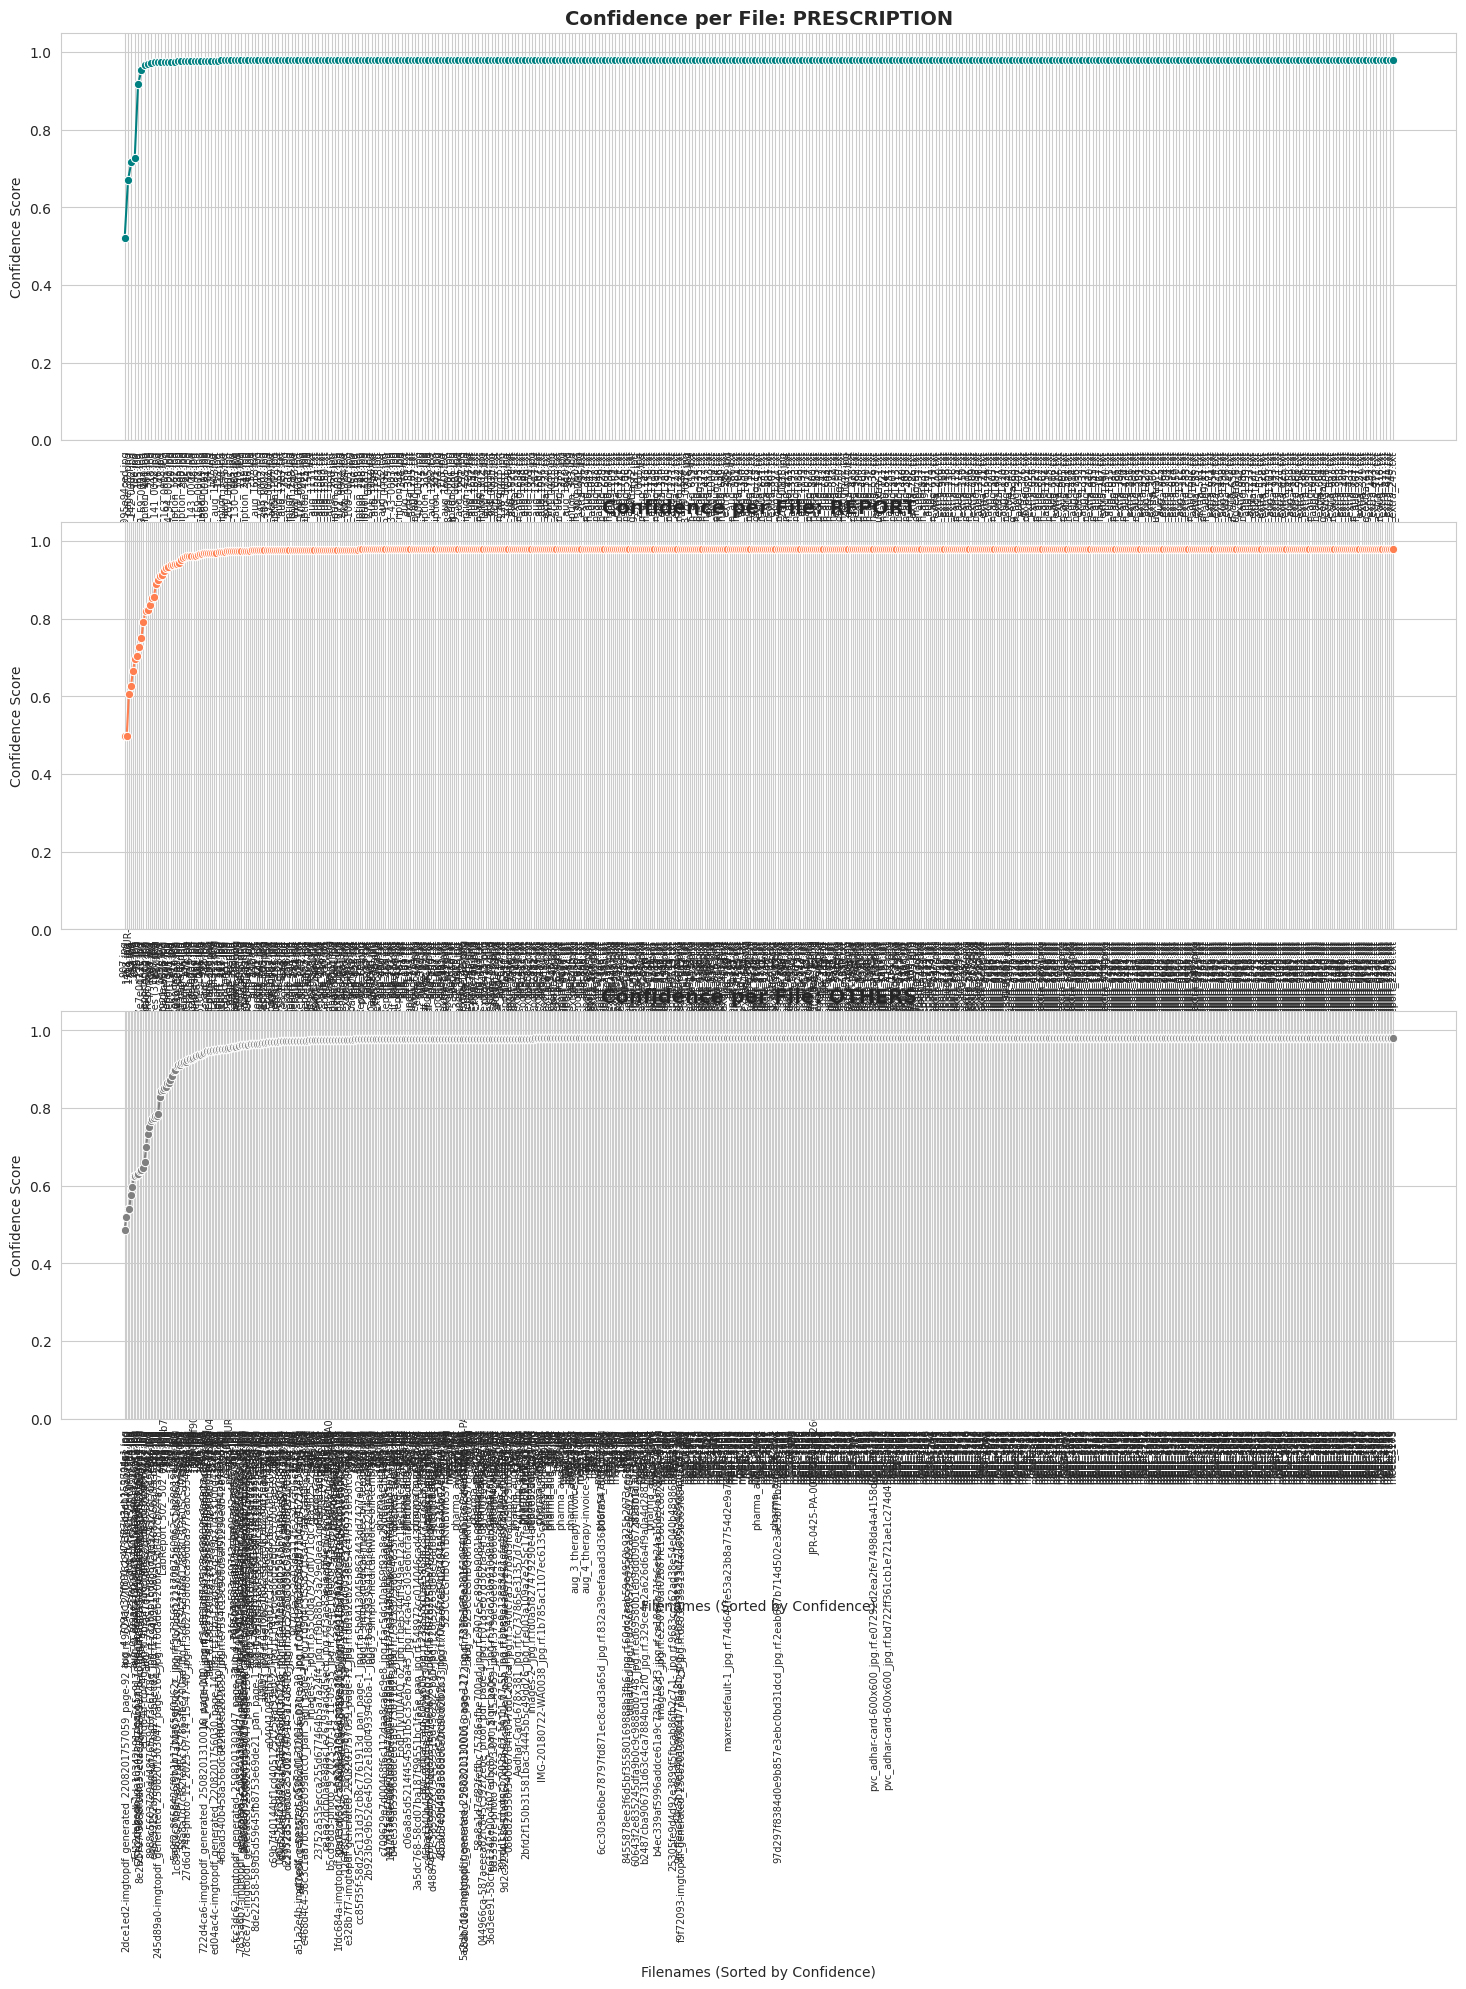

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set global style
sns.set_style("whitegrid")

# Create 3 subplots (one for each class)
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 18))

# Helper function to plot each category
def plot_category(df, label_name, color, ax):
    # Filter for the specific label
    cat_df = df[df['predicted_label'] == label_name].sort_values(by='confidence')
    
    if not cat_df.empty:
        sns.lineplot(data=cat_df, x="filename", y="confidence", marker="o", color=color, ax=ax)
        ax.set_title(f"Confidence per File: {label_name.upper()}", fontsize=14, fontweight='bold')
        ax.set_ylim(0, 1.05)
        ax.set_ylabel("Confidence Score")
        ax.set_xlabel("Filenames (Sorted by Confidence)")
        # Rotate x-labels and shrink font size to handle many files
        ax.tick_params(axis='x', rotation=90, labelsize=7) 
    else:
        ax.set_title(f"No samples found for: {label_name.upper()}")

# --- Plot 1: Prescription (Label 0) ---
plot_category(df_test, "Prescription", "teal", ax1)

# --- Plot 2: Report (Label 1) ---
plot_category(df_test, "Report", "coral", ax2)

# --- Plot 3: Others (Label 2) ---
plot_category(df_test, "Others", "gray", ax3)

plt.tight_layout()
plt.show()


In [152]:
#testing loop
import torch
import pandas as pd
from tqdm import tqdm
import os

# 1. Load the Testing Dataset
test_csv = "V4.0_TEST_FINAL_CLEANED.csv"
if os.path.exists(test_csv):
    df_test = pd.read_csv(test_csv)
    print(f"✅ Loaded {len(df_test)} testing rows.")
else:
    print(f"❌ Error: {test_csv} not found! Check your sidebar.")

# 2. Prediction Loop
predictions = []
# Updated class_map to include the "Others" category
class_map = {0: "Prescription", 1: "Report", 2: "Others"}

print(f"🚀 Running Inference with Safety Gate on {device}...")

model.eval() 
with torch.no_grad():
    for text in tqdm(df_test['text']):
        inputs = tokenizer(str(text), 
                           return_tensors="pt", 
                           truncation=True, 
                           padding=True, 
                           max_length=512).to(device) # Increased to 512 for better report reading
        
        outputs = model(**inputs)
        
        # --- NEW LOGIC START ---
        # 1. Convert raw scores to probabilities
        probs = torch.softmax(outputs.logits, dim=1)
        
        # 2. Get the top 2 highest probabilities
        top_p, top_idx = torch.topk(probs, k=2, dim=1)
        
        conf = top_p[0][0].item()       # Highest probability
        second_p = top_p[0][1].item()   # Second highest
        margin = conf - second_p         # Difference (Margin)
        
        # 3. Apply your Business Rule (Threshold 0.7, Margin 0.3)
        if conf < 0.7 or margin < 0.3:
            pred_idx = 2  # Label for "Others"
        else:
            pred_idx = top_idx[0][0].item() # Original predicted index (0 or 1)
            
        predictions.append(class_map[pred_idx])
        # --- NEW LOGIC END ---

# 3. Add to DataFrame
df_test['predicted_label'] = predictions
# Note: Use class_map.get to handle the case where true label might be missing 2
df_test['true_label_name'] = df_test['label'].map({0: "Prescription", 1: "Report"}) 

# 3. Add to DataFrame
df_test['predicted_label'] = predictions

# Convert labels to names for easy reading
df_test['true_label_name'] = df_test['label'].map(class_map)

# 4. Show Side-by-Side Results
print("\n--- SAMPLE PREDICTIONS ---")
# Show text, true label from folder, and what BERT thought
print(df_test[['filename', 'true_label_name', 'predicted_label']].head(400))

# 5. Save the Results
df_test.to_csv("MODEL_TEST_RESULTS.csv", index=False)
print("\n✅ Results saved to MODEL_TEST_RESULTS.csv")


✅ Loaded 1822 testing rows.
🚀 Running Inference with Safety Gate on cuda...


100%|██████████| 1822/1822 [00:11<00:00, 162.75it/s]


--- SAMPLE PREDICTIONS ---
                                        filename true_label_name  \
0                                      meet_2236          Others   
1                                       meet_572          Others   
2                                         78.jpg    Prescription   
3                      prescription_aug_1420.txt    Prescription   
4                  prescription_aug_extra_63.txt    Prescription   
..                                           ...             ...   
395                                    meet_1094          Others   
396               prescription_aug_extra_109.txt    Prescription   
397                                     1164.jpg          Others   
398                     prescription_aug_187.txt    Prescription   
399  Lab_Report_213_Lab_Report_213_page-0002.jpg          Report   

    predicted_label  
0            Others  
1            Others  
2      Prescription  
3      Prescription  
4      Prescription  
..              ...  
3

In [152]:
#testing loop
import torch
import pandas as pd
from tqdm import tqdm
import os

# 1. Load the Testing Dataset
test_csv = "V4.0_TEST_FINAL_CLEANED.csv"
if os.path.exists(test_csv):
    df_test = pd.read_csv(test_csv)
    print(f"✅ Loaded {len(df_test)} testing rows.")
else:
    print(f"❌ Error: {test_csv} not found! Check your sidebar.")

# 2. Prediction Loop
predictions = []
# Updated class_map to include the "Others" category
class_map = {0: "Prescription", 1: "Report", 2: "Others"}

print(f"🚀 Running Inference with Safety Gate on {device}...")

model.eval() 
with torch.no_grad():
    for text in tqdm(df_test['text']):
        inputs = tokenizer(str(text), 
                           return_tensors="pt", 
                           truncation=True, 
                           padding=True, 
                           max_length=512).to(device) # Increased to 512 for better report reading
        
        outputs = model(**inputs)
        
        # --- NEW LOGIC START ---
        # 1. Convert raw scores to probabilities
        probs = torch.softmax(outputs.logits, dim=1)
        
        # 2. Get the top 2 highest probabilities
        top_p, top_idx = torch.topk(probs, k=2, dim=1)
        
        conf = top_p[0][0].item()       # Highest probability
        second_p = top_p[0][1].item()   # Second highest
        margin = conf - second_p         # Difference (Margin)
        
        # 3. Apply your Business Rule (Threshold 0.7, Margin 0.3)
        if conf < 0.7 or margin < 0.3:
            pred_idx = 2  # Label for "Others"
        else:
            pred_idx = top_idx[0][0].item() # Original predicted index (0 or 1)
            
        predictions.append(class_map[pred_idx])
        # --- NEW LOGIC END ---

# 3. Add to DataFrame
df_test['predicted_label'] = predictions
# Note: Use class_map.get to handle the case where true label might be missing 2
df_test['true_label_name'] = df_test['label'].map({0: "Prescription", 1: "Report"}) 

# 3. Add to DataFrame
df_test['predicted_label'] = predictions

# Convert labels to names for easy reading
df_test['true_label_name'] = df_test['label'].map(class_map)

# 4. Show Side-by-Side Results
print("\n--- SAMPLE PREDICTIONS ---")
# Show text, true label from folder, and what BERT thought
print(df_test[['filename', 'true_label_name', 'predicted_label']].head(400))

# 5. Save the Results
df_test.to_csv("MODEL_TEST_RESULTS.csv", index=False)
print("\n✅ Results saved to MODEL_TEST_RESULTS.csv")


✅ Loaded 1822 testing rows.
🚀 Running Inference with Safety Gate on cuda...


100%|██████████| 1822/1822 [00:11<00:00, 162.75it/s]


--- SAMPLE PREDICTIONS ---
                                        filename true_label_name  \
0                                      meet_2236          Others   
1                                       meet_572          Others   
2                                         78.jpg    Prescription   
3                      prescription_aug_1420.txt    Prescription   
4                  prescription_aug_extra_63.txt    Prescription   
..                                           ...             ...   
395                                    meet_1094          Others   
396               prescription_aug_extra_109.txt    Prescription   
397                                     1164.jpg          Others   
398                     prescription_aug_187.txt    Prescription   
399  Lab_Report_213_Lab_Report_213_page-0002.jpg          Report   

    predicted_label  
0            Others  
1            Others  
2      Prescription  
3      Prescription  
4      Prescription  
..              ...  
3

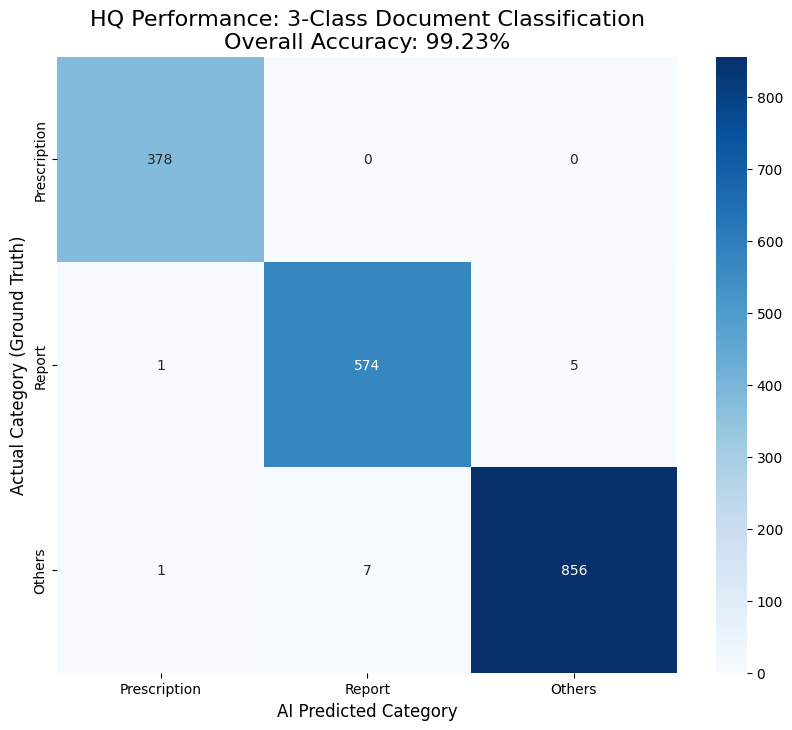

📊 SUMMARY: The model achieved 99.23% accuracy across all document types.

--- Detailed Classification Report ---
              precision    recall  f1-score   support

Prescription       0.99      1.00      1.00       378
      Report       0.99      0.99      0.99       580
      Others       0.99      0.99      0.99       864

    accuracy                           0.99      1822
   macro avg       0.99      0.99      0.99      1822
weighted avg       0.99      0.99      0.99      1822



In [153]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert text predictions back to numbers for comparison
inv_map = {"Prescription": 0, "Report": 1, "Others": 2}
y_pred_numeric = df_test['predicted_label'].map(inv_map)

# 2. CALCULATE ACCURACY
# This is the "Headline" number HQ wants to see first
total_acc = accuracy_score(df_test['label'], y_pred_numeric) * 100

# 3. Generate the numeric confusion matrix
cm = confusion_matrix(df_test['label'], y_pred_numeric)

# 4. Plotting the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=["Prescription", "Report", "Others"],
            yticklabels=["Prescription", "Report", "Others"])

# Added accuracy to the title for visual impact
plt.title(f'HQ Performance: 3-Class Document Classification\nOverall Accuracy: {total_acc:.2f}%', fontsize=16)
plt.ylabel('Actual Category (Ground Truth)', fontsize=12)
plt.xlabel('AI Predicted Category', fontsize=12)
plt.show()

# 5. Print the Full Technical Report for HQ
print(f"📊 SUMMARY: The model achieved {total_acc:.2f}% accuracy across all document types.")
print("\n--- Detailed Classification Report ---")
print(classification_report(df_test['label'], y_pred_numeric, 
                            target_names=["Prescription", "Report", "Others"],
                            labels=[0, 1, 2],
                            zero_division=0))


In [154]:
import os

def get_dir_size(path='best_model'):
    total_size = 0
    if not os.path.exists(path):
        print(f"❌ Folder '{path}' not found.")
        return
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            fp = os.path.join(dirpath, f)
            total_size += os.path.getsize(fp)
    print(f"📦 Total Disk Size: {total_size / (1024 * 1024):.2f} MB")

get_dir_size("best_model")


📦 Total Disk Size: 19.16 MB


In [35]:
def get_model_memory_size(model):
    param_size = 0
    for param in model.parameters():
        param_size += param.nelement() * param.element_size()
    buffer_size = 0
    for buffer in model.buffers():
        buffer_size += buffer.nelement() * buffer.element_size()

    size_all_mb = (param_size + buffer_size) / 1024**2
    print(f"🧠 Model Memory Size: {size_all_mb:.2f} MB")

get_model_memory_size(model)


🧠 Model Memory Size: 18.25 MB


In [155]:
import shutil

shutil.make_archive("Model_7",'zip','best_model_3class')

'/mnt/c38d9ddd-465e-41eb-979c-a8ad51aeb43f6b5230/Files/Bert-Mini/Model_7.zip'